In [3]:
import pandas as pd

In [31]:
data_pursuits = pd.read_csv('data-processed/goal_pursuits.csv')
data_selections = pd.read_csv('data-processed/goal_selections.csv')
data_debrief = pd.read_csv('data-processed/debrief.csv')
selected_goals = pd.read_csv('data-processed/selected_goals.csv')


In [32]:
data_pursuits.head(15)

,timestamp,actor_position,recipient_position,feature,step_number,state_0_type,state_0_shade,state_0_texture,state_1_type,state_1_shade,...,goal_1_shade,goal_1_texture,goal_2_type,goal_2_shade,goal_2_texture,participant_id,trial_number,abandoned,goal_achieved,steps
0,1740261561258,1,0,shape,1,star,light,dots,square,medium,...,medium,plain,square,medium,plain,xoblqmxr2y5olc3ovrzoaufg,1,False,True,6
1,1740261567124,1,0,shape,2,star,light,dots,square,medium,...,medium,plain,square,medium,plain,xoblqmxr2y5olc3ovrzoaufg,1,False,True,6
2,1740261569158,0,2,shape,3,square,light,dots,square,medium,...,medium,plain,square,medium,plain,xoblqmxr2y5olc3ovrzoaufg,1,False,True,6
3,1740261572207,2,0,texture,4,square,light,dots,square,medium,...,medium,plain,square,medium,plain,xoblqmxr2y5olc3ovrzoaufg,1,False,True,6
4,1740261573826,0,1,texture,5,square,light,plain,square,medium,...,medium,plain,square,medium,plain,xoblqmxr2y5olc3ovrzoaufg,1,False,True,6
5,1740261576775,2,0,color,6,square,light,plain,square,medium,...,medium,plain,square,medium,plain,xoblqmxr2y5olc3ovrzoaufg,1,False,True,6
6,1740261590843,0,2,shape,1,circle,dark,stripes,square,medium,...,medium,stripes,star,medium,stripes,xoblqmxr2y5olc3ovrzoaufg,2,False,True,6
7,1740261592523,2,1,shape,2,circle,dark,stripes,square,medium,...,medium,stripes,star,medium,stripes,xoblqmxr2y5olc3ovrzoaufg,2,False,True,6
8,1740261594366,1,0,shape,3,circle,dark,stripes,star,medium,...,medium,stripes,star,medium,stripes,xoblqmxr2y5olc3ovrzoaufg,2,False,True,6
9,1740261595998,0,2,shape,4,star,dark,stripes,star,medium,...,medium,stripes,star,medium,stripes,xoblqmxr2y5olc3ovrzoaufg,2,False,True,6


In [33]:
selected_goals

,participant_id,trial_number,abandoned,goal_achieved,shape_0_type,shape_0_shade,shape_0_texture,shape_1_type,shape_1_shade,shape_1_texture,shape_2_type,shape_2_shade,shape_2_texture
0,xoblqmxr2y5olc3ovrzoaufg,1,False,True,square,medium,plain,square,medium,plain,square,medium,plain
1,xoblqmxr2y5olc3ovrzoaufg,2,False,True,star,medium,stripes,star,medium,stripes,star,medium,stripes
2,xoblqmxr2y5olc3ovrzoaufg,3,False,True,circle,medium,plain,circle,medium,plain,circle,medium,plain
3,xoblqmxr2y5olc3ovrzoaufg,4,False,True,square,medium,dots,square,medium,dots,square,medium,dots
4,xoblqmxr2y5olc3ovrzoaufg,5,False,True,circle,medium,dots,circle,medium,dots,circle,medium,dots
5,lhyr2v0802r5eml5u0y2k1g8,1,False,True,circle,medium,plain,circle,medium,plain,circle,medium,plain
6,lhyr2v0802r5eml5u0y2k1g8,2,False,True,square,medium,stripes,square,medium,stripes,square,medium,stripes
7,lhyr2v0802r5eml5u0y2k1g8,3,False,True,star,medium,plain,star,medium,plain,star,medium,plain
8,lhyr2v0802r5eml5u0y2k1g8,4,False,True,star,medium,stripes,star,medium,stripes,star,medium,stripes
9,lhyr2v0802r5eml5u0y2k1g8,5,False,True,star,light,plain,star,light,plain,star,light,dots


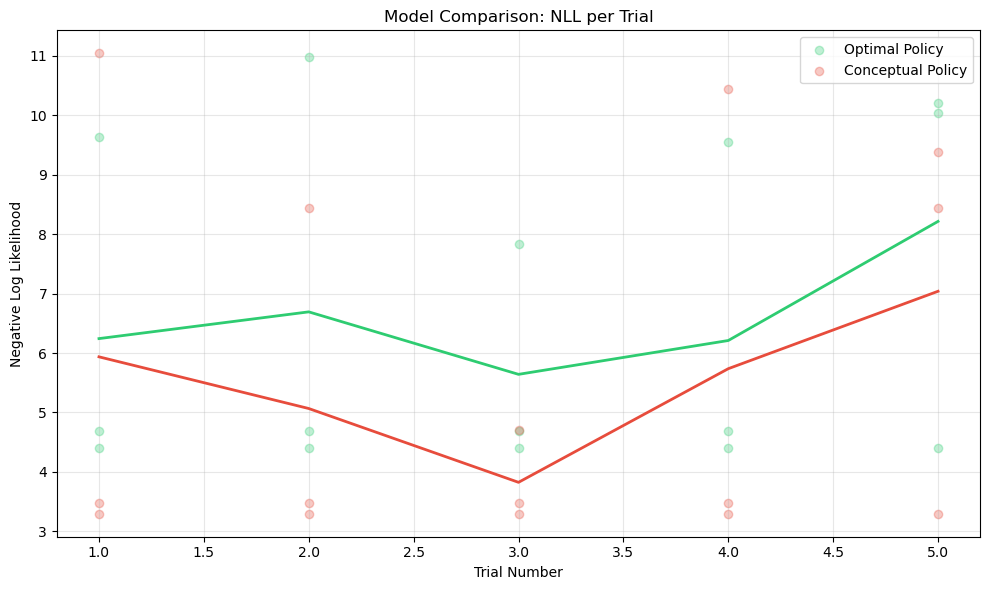


Mean NLL across all trials:
Optimal Policy: 6.600
Conceptual Policy: 5.520


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# Calculate mean NLLs per trial for each model (for the lines)
trial_means = nll_data.groupby('trial_number').agg({
    'optimal_choice_nll': 'mean',
    'conceptual_choice_nll': 'mean'
}).reset_index()

# Create the plot
plt.figure(figsize=(10, 6))

# Plot individual points
plt.scatter(nll_data['trial_number'], nll_data['optimal_choice_nll'], 
           alpha=0.3, color='#2ecc71', label='Optimal Policy')
plt.scatter(nll_data['trial_number'], nll_data['conceptual_choice_nll'], 
           alpha=0.3, color='#e74c3c', label='Conceptual Policy')

# Plot mean lines
plt.plot(trial_means['trial_number'], trial_means['optimal_choice_nll'], 
         '-', color='#2ecc71', linewidth=2)
plt.plot(trial_means['trial_number'], trial_means['conceptual_choice_nll'], 
         '-', color='#e74c3c', linewidth=2)

plt.xlabel('Trial Number')
plt.ylabel('Negative Log Likelihood')
plt.title('Model Comparison: NLL per Trial')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nMean NLL across all trials:")
print(f"Optimal Policy: {nll_data['optimal_choice_nll'].mean():.3f}")
print(f"Conceptual Policy: {nll_data['conceptual_choice_nll'].mean():.3f}")

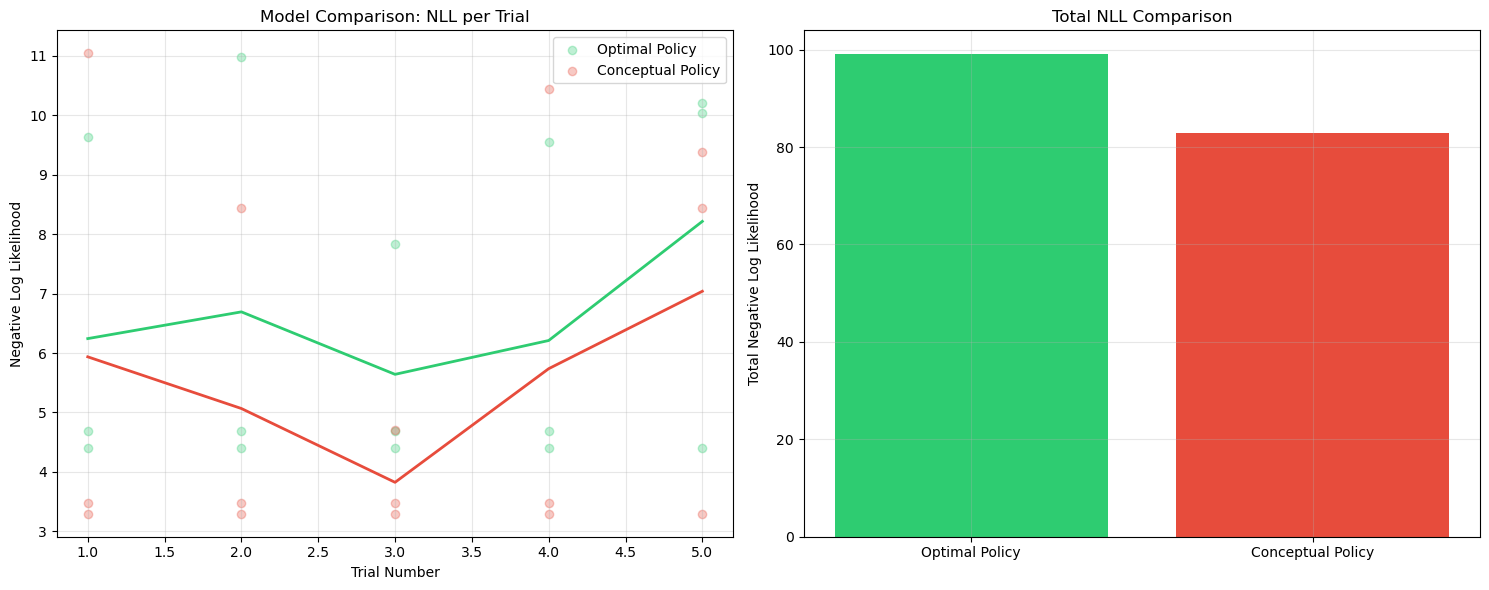


Total NLL:
Optimal Policy: 99.002
Conceptual Policy: 82.801


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
nll_data = pd.read_csv('data-processed/selected_goals_with_nll.csv')

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First subplot: Scatter plot
trial_means = nll_data.groupby('trial_number').agg({
    'optimal_choice_nll': 'mean',
    'conceptual_choice_nll': 'mean'
}).reset_index()

# Plot individual points
ax1.scatter(nll_data['trial_number'], nll_data['optimal_choice_nll'], 
         alpha=0.3, color='#2ecc71', label='Optimal Policy')
ax1.scatter(nll_data['trial_number'], nll_data['conceptual_choice_nll'], 
         alpha=0.3, color='#e74c3c', label='Conceptual Policy')

# Plot mean lines
ax1.plot(trial_means['trial_number'], trial_means['optimal_choice_nll'], 
       '-', color='#2ecc71', linewidth=2)
ax1.plot(trial_means['trial_number'], trial_means['conceptual_choice_nll'], 
       '-', color='#e74c3c', linewidth=2)

ax1.set_xlabel('Trial Number')
ax1.set_ylabel('Negative Log Likelihood')
ax1.set_title('Model Comparison: NLL per Trial')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Second subplot: Bar plot
total_nlls = {
    'Optimal Policy': nll_data['optimal_choice_nll'].sum(),
    'Conceptual Policy': nll_data['conceptual_choice_nll'].sum()
}

colors = {'Optimal Policy': '#2ecc71', 'Conceptual Policy': '#e74c3c'}
ax2.bar(total_nlls.keys(), total_nlls.values(), color=[colors[k] for k in total_nlls.keys()])
ax2.set_ylabel('Total Negative Log Likelihood')
ax2.set_title('Total NLL Comparison')
ax2.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTotal NLL:")
for model, total in total_nlls.items():
    print(f"{model}: {total:.3f}")

In [37]:
nll_data

,participant_id,trial_number,abandoned,goal_achieved,shape_0_type,shape_0_shade,shape_0_texture,shape_1_type,shape_1_shade,shape_1_texture,shape_2_type,shape_2_shade,shape_2_texture,optimal_beta,optimal_total_nll,optimal_choice_nll,conceptual_beta,conceptual_total_nll,conceptual_choice_nll
0,xoblqmxr2y5olc3ovrzoaufg,1,False,True,square,medium,plain,square,medium,plain,square,medium,plain,14.907387,21.972252,4.394450,16.578858,16.479184,3.295837
1,xoblqmxr2y5olc3ovrzoaufg,2,False,True,triangle,medium,stripes,triangle,medium,stripes,triangle,medium,stripes,14.907387,21.972252,4.394450,16.578858,16.479184,3.295837
2,xoblqmxr2y5olc3ovrzoaufg,3,False,True,circle,medium,plain,circle,medium,plain,circle,medium,plain,14.907387,21.972252,4.394450,16.578858,16.479184,3.295837
3,xoblqmxr2y5olc3ovrzoaufg,4,False,True,square,medium,dots,square,medium,dots,square,medium,dots,14.907387,21.972252,4.394450,16.578858,16.479184,3.295837
4,xoblqmxr2y5olc3ovrzoaufg,5,False,True,circle,medium,dots,circle,medium,dots,circle,medium,dots,14.907387,21.972252,4.394450,16.578858,16.479184,3.295837
5,lhyr2v0802r5eml5u0y2k1g8,1,False,True,circle,medium,plain,circle,medium,plain,circle,medium,plain,3.271144,28.979659,4.693670,2.617544,23.263313,3.468823
6,lhyr2v0802r5eml5u0y2k1g8,2,False,True,square,medium,stripes,square,medium,stripes,square,medium,stripes,3.271144,28.979659,4.693670,2.617544,23.263313,3.468823
7,lhyr2v0802r5eml5u0y2k1g8,3,False,True,triangle,medium,plain,triangle,medium,plain,triangle,medium,plain,3.271144,28.979659,4.693670,2.617544,23.263313,3.468823
8,lhyr2v0802r5eml5u0y2k1g8,4,False,True,triangle,medium,stripes,triangle,medium,stripes,triangle,medium,stripes,3.271144,28.979659,4.693670,2.617544,23.263313,3.468823
9,lhyr2v0802r5eml5u0y2k1g8,5,False,True,triangle,low,plain,triangle,low,plain,triangle,low,dots,3.271144,28.979659,10.204980,2.617544,23.263313,9.388021
